### 1. Imports

In [27]:
import os, glob
import sys
import gradio as gr

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from rag.loader import get_documents
from rag.embeddings import init_vectorsotre
from rag.chain import answer_question
from prompts import get_system_prompt,get_judge_prompt
from evaluation.evaluator import evaluate_answer
from config import EMBEDING_MODEL,CHUNK_SIZE,CHUNK_OVERLAP,OPENAI_KEY
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter
import umap
from sklearn.preprocessing import LabelEncoder
import tiktoken



### 2. Load All Documents, Categories

In [2]:
documents, categories = get_documents()

### 3. Create or Load VectorStore

In [3]:
init_vectorsotre()

### 4. Define System Prompt

In [4]:
SYSTEM_PROMPT = get_system_prompt()


### 5. Run Gradio Chat Interface

In [5]:
select_categories = gr.Dropdown(
    categories,
    label="Select Category",
)
gr.ChatInterface(
    fn=answer_question,
    title="TechNova RAG Assistant",
    additional_inputs=select_categories,
   
).launch(server_name="0.0.0.0", server_port=7860,inline=False)

* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.


### 6. Evaluate Result

In [6]:
evaluate_answer()

{'summary': {'total_questions': 29,
  'retrieval_precision': 0.931,
  'answer_score_avg': 4.76,
  'refused_correctly': True},
 'per_question': [{'id': 'q01',
   'question': 'What is the battery capacity of the Nova Phone X1 and how fast does it charge?',
   'predicted_answer': 'The Nova Phone X1 has a battery capacity of 5000mAh and supports 65W fast charging.',
   'retrieved_sources': ['/Users/admin/Desktop/Assessment 2/technova_rag_assistant/products/nova_phone_x1.md',
    '/Users/admin/Desktop/Assessment 2/technova_rag_assistant/support_tickets/ticket_001.md',
    '/Users/admin/Desktop/Assessment 2/technova_rag_assistant/release_notes/novaos_5_1.md'],
   'score': 5},
  {'id': 'q02',
   'question': 'How much does the base configuration of the Nova Laptop Pro 14 cost?',
   'predicted_answer': 'The base configuration of the Nova Laptop Pro 14 (16GB / 512GB) costs $1,799.',
   'retrieved_sources': ['/Users/admin/Desktop/Assessment 2/technova_rag_assistant/products/nova_laptop_pro.md',
 

### 7. Visualize Data


#### 7.1 Knowledge Base Overview: Documents per Category

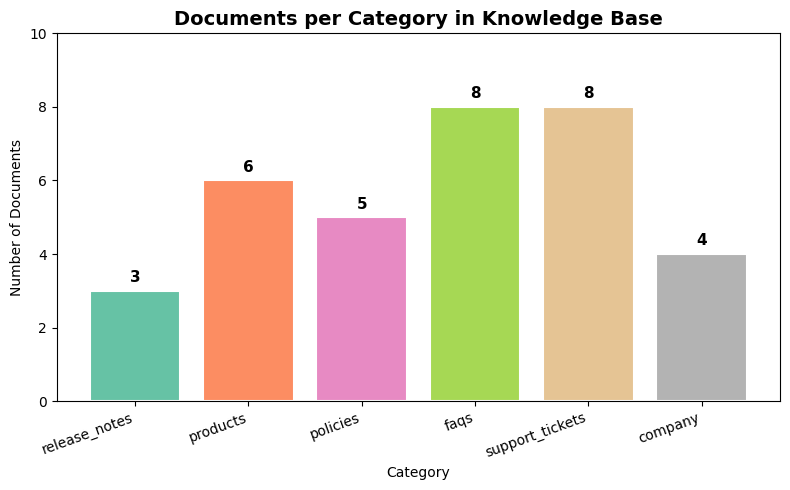

In [9]:
folders = glob.glob("../knowledge-base/*")
category_counts = {}
for folder in folders:
    doc_category = os.path.basename(folder)
    files = glob.glob(os.path.join(folder, "**/*.md"), recursive=True)
    category_counts[doc_category] = len(files)

categories = list(category_counts.keys())
counts = list(category_counts.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(categories, counts, color=colors, edgecolor="white", linewidth=1.5)
ax.bar_label(bars, padding=4, fontsize=11, fontweight="bold")
ax.set_title("Documents per Category in Knowledge Base", fontsize=14, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Documents")
ax.set_ylim(0, max(counts) + 2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

#### 7.2 Token Count per Category

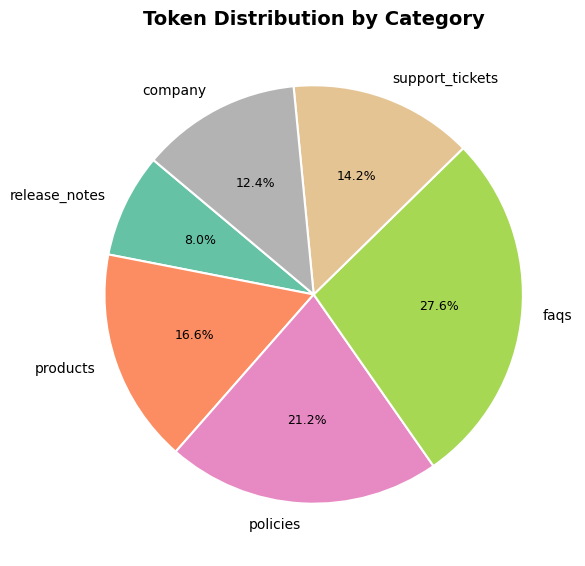

In [18]:
encoding = tiktoken.encoding_for_model(EMBEDING_MODEL)

category_tokens = {}
for folder in folders:
    doc_category = os.path.basename(folder)
    total = 0
    for f in glob.glob(os.path.join(folder, "**/*.md"), recursive=True):
        with open(f, "r", encoding="utf-8") as fh:
            total += len(encoding.encode(fh.read()))
    category_tokens[doc_category] = total

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    category_tokens.values(),
    labels=category_tokens.keys(),
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title("Token Distribution by Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### 7.3 Chunk Size Distribution (after text splitting)

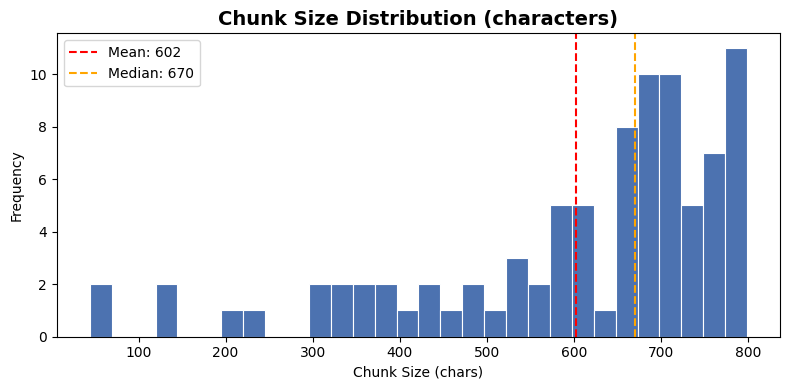

In [19]:
text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP
)
documents, _ = get_documents()
chunks = text_splitter.split_documents(documents)

chunk_lengths = [len(chunk.page_content) for chunk in chunks]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(chunk_lengths, bins=30, color="#4C72B0", edgecolor="white", linewidth=0.8)
ax.axvline(
    np.mean(chunk_lengths),
    color="red",
    linestyle="--",
    label=f"Mean: {np.mean(chunk_lengths):.0f}",
)
ax.axvline(
    np.median(chunk_lengths),
    color="orange",
    linestyle="--",
    label=f"Median: {np.median(chunk_lengths):.0f}",
)
ax.set_title("Chunk Size Distribution (characters)", fontsize=14, fontweight="bold")
ax.set_xlabel("Chunk Size (chars)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

#### 7.4 Chunks per doc_category

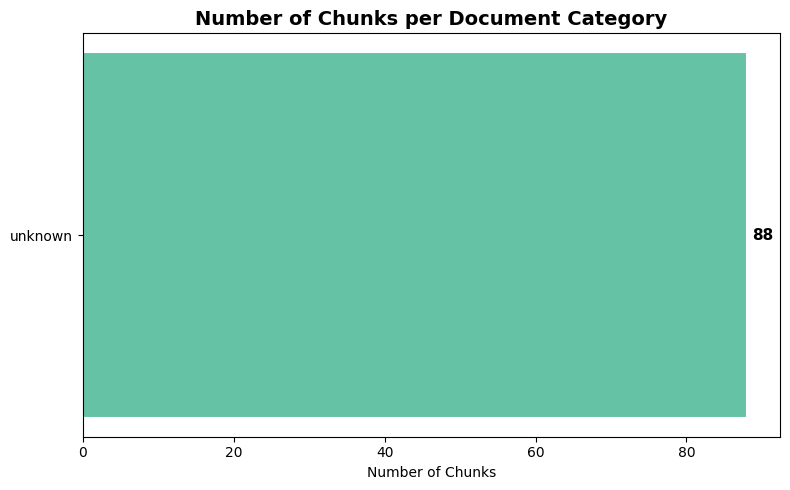

In [20]:
chunk_by_category = Counter(
    chunk.metadata.get("doc_category", "unknown") for chunk in chunks
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    list(chunk_by_category.keys()),
    list(chunk_by_category.values()),
    color=colors[: len(chunk_by_category)],
    edgecolor="white",
    linewidth=1.5,
)
ax.bar_label(bars, padding=4, fontsize=11, fontweight="bold")
ax.set_title("Number of Chunks per Document Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Chunks")
plt.tight_layout()
plt.show()

#### 7.5 2D Embedding Visualisation with UMAP/TSNE

/Users/admin/Desktop/Assessment 2/technova_rag_assistant/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


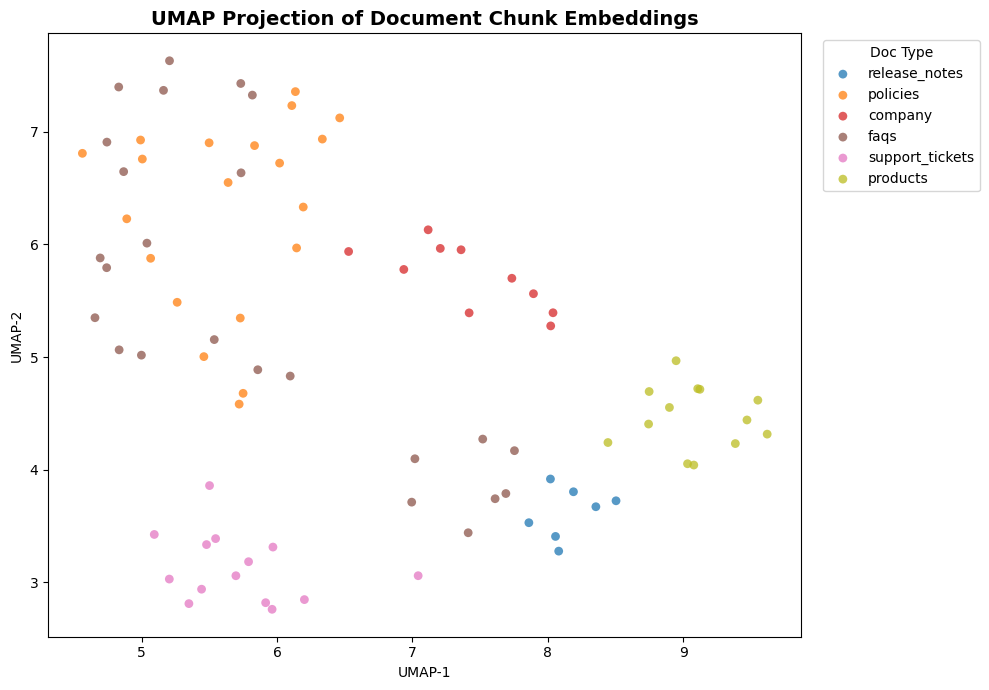

In [28]:
texts = [c.page_content for c in chunks]
labels = [c.metadata.get("category", "unknown") for c in chunks]

if not texts:
    raise ValueError("No chunks found. Run the document loading and chunking cells first.")

embedding_model = OpenAIEmbeddings(model=EMBEDING_MODEL, api_key=OPENAI_KEY)
embeddings_raw = embedding_model.embed_documents(texts)
embeddings_np = np.array(embeddings_raw)

reducer = umap.UMAP(n_components=2, random_state=42)
reduced = reducer.fit_transform(embeddings_np)

unique_labels = list(set(labels))
color_map = {
    lbl: plt.cm.tab10(i / len(unique_labels)) for i, lbl in enumerate(unique_labels)
}

fig, ax = plt.subplots(figsize=(10, 7))
for lbl in unique_labels:
    idx = [i for i, l in enumerate(labels) if l == lbl]
    ax.scatter(
        reduced[idx, 0],
        reduced[idx, 1],
        label=lbl,
        color=color_map[lbl],
        s=40,
        alpha=0.75,
        edgecolors="none",
    )

ax.set_title(
    "UMAP Projection of Document Chunk Embeddings", fontsize=14, fontweight="bold"
)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(title="Doc Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()